In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import sys
import os
import numpy as np
from datetime import datetime
np.NaN=np.nan
import pandas_ta as ta
import importlib
from typing import Tuple
import vectorbt as vbt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import tqdm 
from tabulate import tabulate
import warnings
import re
import time
from tvDatafeed import TvDatafeed, Interval

warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)


In [8]:
import pandas as pd

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) 
pd.set_option('display.max_colwidth', None)

##### These variables can be changed


In [9]:
#Input file
input_list='input/ind_nifty50list.csv'
#General variables
START_DATE = "2017-01-01"
TRADING_START_DATE = "2018-01-01"
END_DATE = "2024-06-01"                 #datetime.today().strftime('%Y-%m-%d')

# Zscore generation
ROLLING_THRESHOLD     = -99999
ROLLING_PERIOD        = 16
MEAN_PERIOD           = 28

# Weights Generation
Z_MEAN                = True
FREQUENCY             = 'monthly'      # "weekly" or "monthly"
INITIAL_CAPITAL       = 100000
NUM_STOCKS_ACTIVE     = 30
ZSCORE_THRESHOLD      = 0.1
ZSCORE_PERIOD         = 24

DILUTE_TO = 15

INPUT_SYMBOLS=[
  "3MINDIA",
  "AARTIIND",
  "ABB",
  "ABBOTINDIA",
  "ABFRL",
  "ABREL",
  "ACC",
  "ACE",
  "ADANIENT",
  "ADANIGREEN",
  "ADANIPORTS",
  "ADANITRANS",
  "ADVENZYMES",
  "AEGISCHEM",
  "AFFLE",
  "AIAENG"
]
INPUT_MODE='csv'    #'list' or 'csv'


# Fetch Data


In [10]:
username = "rialto364@gmail.com"
password = "TradingView@@123"
tv = TvDatafeed(username, password)

def clean_symbol(symbol):
    """Cleans the symbol name to be compatible with the API."""
    return re.sub(r'[^\w]', '_', symbol)

def fill_gaps_with_boundary_mean(df):

    ffill_val = df.ffill()
    bfill_val = df.bfill()
    filled_df = (ffill_val + bfill_val) / 2
    
    # 4. Fill original NaNs (Stocks starting/ending with NaNs will remain NaN)
    return df.fillna(filled_df)

def fetch_and_save_ohlcv(symbols_input, start_date=None, end_date=None, update=False):
    # --- 1. Symbol Input Processing ---
    symbols_list = []
    if isinstance(symbols_input, list):
        print("Processing symbols from the provided list.")
        symbols_list = symbols_input
    elif isinstance(symbols_input, str):
        try:
            print(f"Reading symbols from CSV file: {symbols_input}")
            symbols_list = pd.read_csv(symbols_input)['Symbol'].tolist()
        except Exception as e:
            print(f"Error reading symbols input: {e}")
            return []
    if not symbols_list:
        print("No symbols to process.")
        return []

    # --- 2. Bar Calculation Logic ---
    n_bars = 5000
    if start_date:
        start_date_dt = pd.to_datetime(start_date)
        days_diff = (datetime.now() - start_date_dt).days
        n_bars = ((days_diff * 5) // 7) + 50
        print(f"Start date provided. Calculating required bars: approx. {n_bars}")

    data_dict = {}
    failed_symbols = []
    
    # --- 3. Data Fetching Loop with Retry Logic ---
    retries = 3 
    
    print(f"--- Fetching data for {len(symbols_list)} symbols ---")
    
    # CHANGED: Use tqdm.tqdm to access the class explicitly
    for symbol in tqdm.tqdm(symbols_list, desc="Fetching Stocks", unit="symbol"):
        for attempt in range(retries):
            try:
                cleaned_symbol = clean_symbol(symbol)
                data = tv.get_hist(symbol=cleaned_symbol, exchange='NSE', interval=Interval.in_daily, n_bars=n_bars)
                time.sleep(0.5)
                
                if data is None or data.empty:
                    # CHANGED: Use tqdm.tqdm.write
                    #tqdm.tqdm.write(f"No data for {symbol} (Attempt {attempt+1}/{retries})")
                    time.sleep(0.5) 
                    continue 

                df = pd.DataFrame(data); df.index = pd.to_datetime(df.index)
                if start_date: df = df[df.index >= pd.to_datetime(start_date)]
                if end_date: df = df[df.index <= pd.to_datetime(end_date)]

                if df.empty:
                    #tqdm.tqdm.write(f"No data for {symbol} in date range.")
                    break 
                
                # Save the data using the symbol with the .NS suffix as the key
                data_dict[symbol + ".NS"] = df[['open', 'high', 'low', 'close', 'volume']]
                
                time.sleep(1) 
                break 
                
            except Exception as e:
                #tqdm.tqdm.write(f"Error processing {symbol} (Attempt {attempt + 1}/{retries}): {e}")
                
                if "Connection to remote host was lost" in str(e) and attempt < retries - 1:
                    wait_time = (attempt + 1) * 5 
                    tqdm.tqdm.write(f"Connection lost. Retrying in {wait_time} seconds...")
                    time.sleep(wait_time)
                else:
                    failed_symbols.append(symbol)
                    break 
            
    if not data_dict:
        print("No data was successfully fetched."); return failed_symbols

    # --- 4. Optimized Saving, Cleaning & Splitting Logic ---
    output_dir = "split_ohlcv_data"
    if not os.path.exists(output_dir): os.makedirs(output_dir)
    
    master_file_path = os.path.join(output_dir, "all_ohlcv.csv")

    try:
        print("\n--- Processing Data ---")
        
        # 1. Create a Master DataFrame from the currently fetched data (No cleaning yet)
        current_master_df = pd.concat(data_dict, axis=1)
        
        # --- FIX 1: Set index name to None immediately ---
        current_master_df.index.name = None 

        # 2. Handle Update Mode (Merge current fetch with existing file)
        if update and os.path.exists(master_file_path):
            print("Update mode active: Merging with existing Master file...")
            existing_master = pd.read_csv(master_file_path, index_col=0, parse_dates=True, header=[0, 1])
            
            # --- FIX 2: Sanitize existing data ---
            if 'Date' in existing_master.index:
                print("Removing corrupted 'Date' row from existing file...")
                existing_master = existing_master.drop('Date')
            
            # Ensure index is datetime
            existing_master.index = pd.to_datetime(existing_master.index, errors='coerce')
            existing_master = existing_master[~existing_master.index.isna()]

            # Combine: update existing values with new ones
            master_df = existing_master.combine_first(current_master_df)
            master_df.update(current_master_df) 
        else:
            master_df = current_master_df

        # --- FIX 3: Ensure index name is None for the FINAL dataframe ---
        master_df.index.name = None

        # 3. CLEANING: Fill gaps (Performed ONLY on the final, combined DataFrame)
        print("Cleaning missing values (mean of boundaries)...")
        master_df = fill_gaps_with_boundary_mean(master_df)

        # 4. Save the Consolidated Master File
        master_df.to_csv(master_file_path)
        print(f"✅ Successfully saved Cleaned Master Data to '{master_file_path}'")

        # 5. Split into individual OHLCV files
        print("Splitting Master file into individual attribute files...")
        attributes = ['open', 'high', 'low', 'close', 'volume']
        
        for attr in attributes:
            # Use xs (Cross Section) to grab all columns for a specific attribute level
            attr_df = master_df.xs(attr, axis=1, level=1)
            
            # --- FIX 4: Explicitly set index name to 'Date' for single-level files ---
            attr_df.index.name = 'Date'
            
            output_file = os.path.join(output_dir, f"all_{attr}.csv")
            attr_df.to_csv(output_file)
            print(f"   -> Saved all_{attr}.csv")

    except Exception as e:
        print(f"❌ Critical Error during save/split process: {e}")
        return failed_symbols

    print(f"\nAll files saved successfully in '{output_dir}'!")
    return failed_symbols

In [11]:
def smart_fetch_ohlcv(symbols_input, start_date=None, end_date=None):
    """
    Intelligently fetches OHLCV data by checking existing data and only fetching missing ranges.
    Args:
        symbols_input: Either a list of symbols or path to CSV file
        start_date: Start date for data (YYYY-MM-DD)
        end_date: End date for data (YYYY-MM-DD)
    
    Returns:
        List of failed symbols
    """
    import os
    import pandas as pd
    from datetime import datetime
    
    # --- 1. Process Symbol Input ---
    symbols_list = []
    if isinstance(symbols_input, list):
        print("Processing symbols from the provided list.")
        symbols_list = symbols_input
    if not symbols_list:
        print("No symbols to process.")
        return []
    
    # Add .NS suffix to symbols for comparison
    requested_symbols = set([sym + ".NS" for sym in symbols_list])
    
    # --- 2. Check if existing data file exists ---
    master_file_path = "split_ohlcv_data/all_close.csv"
    
    if not os.path.exists(master_file_path):
        print("No existing data found. Performing complete fetch...")
        return fetch_and_save_ohlcv(symbols_input, start_date, end_date, update=False)
    
    # --- 3. Read existing data ---
    try:
        existing_data = pd.read_csv(master_file_path, index_col=0, parse_dates=True)
        existing_symbols = set(existing_data.columns)
        
        # Get date range of existing data
        existing_start = existing_data.index.min()
        existing_end = existing_data.index.max()
        
        print(f"\n--- Existing Data Summary ---")
        print(f"Symbols in file: {len(existing_symbols)}")
        print(f"Date range: {existing_start.date()} to {existing_end.date()}")
        
    except Exception as e:
        print(f"Error reading existing data: {e}")
        print("Performing complete fetch...")
        return fetch_and_save_ohlcv(symbols_input, start_date, end_date, update=False)
    
    # --- 4. Check if symbols match ---
    if requested_symbols != existing_symbols:
        print(f"\n⚠️ Symbol mismatch detected!")
        print("\nPerforming complete fetch with new symbol list...")
        return fetch_and_save_ohlcv(symbols_input, start_date, end_date, update=False)
    
    # --- 5. Symbols match - check date ranges ---
    print(f"\n✅ Symbols match! Checking date ranges...")
    
    requested_start = pd.to_datetime(start_date) if start_date else None
    requested_end = pd.to_datetime(end_date) if end_date else pd.Timestamp(datetime.today())
    
    needs_fetch_before = False
    needs_fetch_after = False
    needs_clip_start = False
    needs_clip_end = False
    
    # Check if we need to fetch data before existing start
    if requested_start and requested_start < existing_start:
        needs_fetch_before = True
        print(f"📥 Need to fetch data BEFORE {existing_start.date()}")
    elif requested_start and requested_start > existing_start:
        needs_clip_start = True
        print(f"✂️ Will clip data to start from {requested_start.date()}")
    # Check if we need to fetch data after existing end
    if requested_end > existing_end:
        needs_fetch_after = True
        print(f"📥 Need to fetch data AFTER {existing_end.date()}")
    elif requested_end < existing_end:
        needs_clip_end = True
        print(f"✂️ Will clip data to end at {requested_end.date()}")
    
    # --- 6. Handle fetching and clipping ---
    failed_symbols = []
    
    # Fetch missing data before
    if needs_fetch_before:
        print(f"\n--- Fetching data from {requested_start.date()} to {existing_start.date()} ---")
        failed_before = fetch_and_save_ohlcv(
            symbols_input,
            start_date=requested_start.strftime('%Y-%m-%d'),
            end_date=(existing_start - pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
            update=True
        )
        failed_symbols.extend(failed_before)
    
    # Fetch missing data after
    if needs_fetch_after:
        print(f"\n--- Fetching data from {existing_end.date()} to {requested_end.date()} ---")
        failed_after = fetch_and_save_ohlcv(
            symbols_input,
            start_date=(existing_end + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
            end_date=requested_end.strftime('%Y-%m-%d'),
            update=True
        )
        failed_symbols.extend(failed_after)
    
    # Clip data if needed
    if needs_clip_start or needs_clip_end:
        print(f"\n--- Clipping data to requested range ---")
        try:
            # Reload the master file after potential updates
            master_df = pd.read_csv("split_ohlcv_data/all_ohlcv.csv", index_col=0, parse_dates=True, header=[0, 1])
            
            # Clip to requested range
            clip_start = requested_start if requested_start else master_df.index.min()
            clip_end = requested_end if requested_end else master_df.index.max()
            
            master_df = master_df.loc[clip_start:clip_end]
            
            # Save clipped master file
            master_df.to_csv("split_ohlcv_data/all_ohlcv.csv")
            print(f"✅ Clipped master data to {master_df.index.min().date()} - {master_df.index.max().date()}")
            
            # Re-split into individual files
            print("Updating individual attribute files...")
            attributes = ['open', 'high', 'low', 'close', 'volume']
            for attr in attributes:
                attr_df = master_df.xs(attr, axis=1, level=1)
                attr_df.index.name = 'Date'
                output_file = f"split_ohlcv_data/all_{attr}.csv"
                attr_df.to_csv(output_file)
                print(f"   -> Updated all_{attr}.csv")
                
        except Exception as e:
            print(f"❌ Error during clipping: {e}")
    
    # --- 7. Report results ---
    if not needs_fetch_before and not needs_fetch_after and not needs_clip_start and not needs_clip_end:
        print(f"\n✅ All data already up to date! No fetching or clipping needed.")
    else:
        print(f"\n✅ Smart fetch completed!")
    
    # --- 8. Retry failed symbols with complete fetch ---
    if failed_symbols:
        print(f"\n⚠️ Found {len(failed_symbols)} failed symbols: {failed_symbols}")
        print(f"🔄 Retrying failed symbols with complete fetch...")
        
        retry_failed = fetch_and_save_ohlcv(
            failed_symbols,
            start_date=start_date,
            end_date=end_date,
            update=True
        )
        
        if retry_failed:
            print(f"\n❌ Still failed after retry: {retry_failed}")
            return retry_failed
        else:
            print(f"\n✅ All failed symbols successfully fetched on retry!")
            return []
    else:
        print(f"\n✅ Complete fetch successful on first try!")
        return []


In [12]:
if INPUT_MODE=='csv':
    input_list_df = pd.read_csv(input_list)
    symbols_to_fetch = input_list_df['Symbol'].tolist()
else:
    symbols_to_fetch=INPUT_SYMBOLS
smart_fetch_ohlcv(symbols_to_fetch,start_date=START_DATE,end_date=END_DATE)

Processing symbols from the provided list.

--- Existing Data Summary ---
Symbols in file: 21
Date range: 2018-01-01 to 2022-12-30

⚠️ Symbol mismatch detected!

Performing complete fetch with new symbol list...
Processing symbols from the provided list.
Start date provided. Calculating required bars: approx. 2400
--- Fetching data for 50 symbols ---


Fetching Stocks:  10%|█         | 5/50 [00:11<01:42,  2.28s/symbol]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
Fetching Stocks:  12%|█▏        | 6/50 [00:14<01:56,  2.65s/symbol]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
Fetching Stocks:  26%|██▌       | 13/50 [00:33<01:25,  2.30s/symbol]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
Fetching Stocks:  32%|███▏      | 16/50 [00:41<01:24,  2.49s/symbol]ERROR:tvDatafeed.main:Connection to remote host was lost.
ERROR:tvDatafeed.main:no data, please check the exchange and symbol
Fetching Stocks: 100%|██████████| 50/50 [00:52<00:00,  1.05s/symbol]



--- Processing Data ---
Cleaning missing values (mean of boundaries)...
✅ Successfully saved Cleaned Master Data to 'split_ohlcv_data/all_ohlcv.csv'
Splitting Master file into individual attribute files...
   -> Saved all_open.csv
   -> Saved all_high.csv
   -> Saved all_low.csv
   -> Saved all_close.csv
   -> Saved all_volume.csv

All files saved successfully in 'split_ohlcv_data'!


['HDFCLIFE',
 'HEROMOTOCO',
 'HINDALCO',
 'HINDUNILVR',
 'ICICIBANK',
 'ITC',
 'INDUSINDBK',
 'INFY',
 'JSWSTEEL',
 'JIOFIN',
 'KOTAKBANK',
 'LT',
 'M&M',
 'MARUTI',
 'NTPC',
 'NESTLEIND',
 'ONGC',
 'POWERGRID',
 'RELIANCE',
 'SBILIFE',
 'SHRIRAMFIN',
 'SBIN',
 'SUNPHARMA',
 'TCS',
 'TATACONSUM',
 'TATAMOTORS',
 'TATASTEEL',
 'TECHM',
 'TITAN',
 'TRENT',
 'ULTRACEMCO',
 'WIPRO']

# Zscore & Weights----------------------- 


In [20]:
def get_vix_rebalancing_dates(
    start_date, 
    end_date, 
    vix_filepath='src/vix_daily_ohlcv.csv',
    rising_open_threshold=15, 
    rising_pct_threshold=10.5, 
    falling_open_threshold=22, 
    falling_pct_threshold=-15
):
    # Load VIX data
    try:
        vix_data = pd.read_csv(vix_filepath, header=[0, 1], index_col=0, parse_dates=True)
    except FileNotFoundError:
        print(f"Error: VIX data file not found at {vix_filepath}")
        return [], [], []
    except Exception as e:
        print(f"Error loading VIX data: {e}")
        return [], [], []

    # --- FIX 1: Remove any rows with invalid dates (NaT) in the index ---
    vix_data = vix_data[vix_data.index.notna()]

    # --- FIX 2: Standardize index to be timezone-naive to prevent comparison issues ---
    try:
        # This removes any timezone info (e.g., 'UTC')
        vix_data.index = vix_data.index.tz_localize(None)
    except TypeError:
        # Index is already naive, which is fine.
        pass

    # --- FIX 3: Sort the index to allow date slicing ---
    vix_data.sort_index(inplace=True)

    # --- FIX 4: Remove duplicate index entries (dates) ---
    # A non-unique index can also cause the "non-monotonic" error
    vix_data = vix_data[~vix_data.index.duplicated(keep='first')]

    # Standardize start/end dates to be naive Timestamps for robust slicing
    try:
        start_ts = pd.Timestamp(start_date).tz_localize(None)
        end_ts = pd.Timestamp(end_date).tz_localize(None)
    except Exception as e:
        print(f"Error parsing start_date or end_date: {e}")
        return [], [], []
        
    # Slice data to the relevant date range
    # This line should now work correctly
    vix_data = vix_data.loc[start_ts:end_ts]

    if vix_data.empty:
        print(f"No VIX data found for the period {start_ts} to {end_ts}")
        return [], [], []

    # --- Vectorized Calculation ---

    # Extract Open and Close values
    try:
        open_val = vix_data[("^INDIAVIX", "Open")]
        close_val = vix_data[("^INDIAVIX", "Close")]
    except KeyError:
        print("Error: ('^INDIAVIX', 'Open') or ('^INDIAVIX', 'Close') not found in CSV columns.")
        print("Available columns are:", vix_data.columns.tolist())
        return [], [], []

    # Calculate percentage change
    pct_change = ((close_val - open_val) / open_val) * 100

    # Rising VIX condition (vectorized)
    rising_mask = (open_val < rising_open_threshold) & (pct_change > rising_pct_threshold)

    # Falling VIX condition (vectorized)
    falling_mask = (open_val > falling_open_threshold) & (pct_change < falling_pct_threshold)

    # Get the dates where conditions are True
    rebal_rising = vix_data[rising_mask].index.tolist()
    rebal_falling = vix_data[falling_mask].index.tolist()

    # Merge and sort the final lists
    merged_dates = sorted(rebal_rising + rebal_falling)

    return rebal_rising, rebal_falling, merged_dates
if __name__ == '__main__':
    VIX_FILE_PATH = 'src/vix_daily_ohlcv.csv' # Make sure this path is correct

    # Call the function
    vix_rising, vix_falling, merged_vix_dates = get_vix_rebalancing_dates(
        start_date=START_DATE,
        end_date=END_DATE,
        vix_filepath=VIX_FILE_PATH
    )

    # Print the results
    print(f"--- VIX Rebalancing Dates from {START_DATE} to {END_DATE} ---")
    
    print(f"\nTotal Rising VIX Dates: {len(vix_rising)}")
    print("First 15 Rising Dates:", vix_rising[:15])
    
    print(f"\nTotal Falling VIX Dates: {len(vix_falling)}")
    print("First 15 Falling Dates:", vix_falling[:15])
    
    print(f"\nTotal Merged VIX Dates: {len(merged_vix_dates)}")
    print("First 15 Merged Dates:", merged_vix_dates[:15])

--- VIX Rebalancing Dates from 2017-01-01 to 2024-06-01 ---

Total Rising VIX Dates: 19
First 15 Rising Dates: [Timestamp('2017-05-18 00:00:00'), Timestamp('2017-09-04 00:00:00'), Timestamp('2018-09-21 00:00:00'), Timestamp('2018-12-21 00:00:00'), Timestamp('2020-01-03 00:00:00'), Timestamp('2020-01-06 00:00:00'), Timestamp('2020-02-24 00:00:00'), Timestamp('2021-07-08 00:00:00'), Timestamp('2021-11-22 00:00:00'), Timestamp('2022-12-21 00:00:00'), Timestamp('2023-01-27 00:00:00'), Timestamp('2023-02-22 00:00:00'), Timestamp('2023-03-13 00:00:00'), Timestamp('2023-09-28 00:00:00'), Timestamp('2023-10-09 00:00:00')]

Total Falling VIX Dates: 3
First 15 Falling Dates: [Timestamp('2019-05-20 00:00:00'), Timestamp('2019-05-23 00:00:00'), Timestamp('2022-02-25 00:00:00')]

Total Merged VIX Dates: 22
First 15 Merged Dates: [Timestamp('2017-05-18 00:00:00'), Timestamp('2017-09-04 00:00:00'), Timestamp('2018-09-21 00:00:00'), Timestamp('2018-12-21 00:00:00'), Timestamp('2019-05-20 00:00:00'), T

In [21]:
def z_score(rolling_threshold, period, mean_period,mode='normal'):
    # --- 1. Common Part: Load and Prepare Data ---
    if INPUT_MODE=='csv':
        symbols_df = pd.read_csv(input_list)
        symbols = symbols_df['Symbol'].tolist()
    else:
        symbols=INPUT_SYMBOLS

    weekly_close = pd.read_csv('src/cleaned_weekly_data.csv', parse_dates=['Date'], index_col='Date')
    
    #zscore calculation
    weekly_returns = np.log(weekly_close / weekly_close.shift(1))
    rolling_mean = weekly_returns.rolling(window=period).mean()
    rolling_std = weekly_returns.rolling(window=period).std()

    # Calculate z-scores with proper handling of division by zero
    # Add small epsilon to prevent division by zero
    epsilon = 1e-10
    rolling_std_safe = rolling_std.replace(0, epsilon)
    
    # Calculate z-scores safely
    z_scores = (weekly_returns - rolling_mean) / rolling_std_safe
    
    # Create the Z-Scores DataFrame
    z_scores_df = pd.DataFrame(z_scores, index=weekly_returns.index, columns=weekly_returns.columns)
    
    # Replace inf and -inf with NaN, then fill NaN with 0
    z_scores_df = z_scores_df.replace([np.inf, -np.inf], np.nan)
    z_scores_df = z_scores_df.fillna(0)
    
    # Compute rolling mean of period 'mean_period' for Z-scores
    z_scores_mean_df = z_scores_df.rolling(window=mean_period).mean()
    
    # Handle inf values only (keep NaN as NaN for warm-up period)
    z_scores_mean_df = z_scores_mean_df.replace([np.inf, -np.inf], np.nan)
    
    # Do NOT fill NaN values in the rolling mean during warm-up period
    # Each mean_period will naturally have NaN for its first (mean_period-1) rows
    # This ensures distinct behavior: mean_period=20 starts giving signals at row 20,
    # mean_period=24 starts at row 24, etc.
    # The stock selection logic will handle NaN by using dropna()
    
    if mode=='normal':
        z_scores_df.to_csv('auxilary/z_scores.csv')
        z_scores_mean_df.to_csv('auxilary/z_scores_mean.csv')
        print("Z-Score calculation completed and files saved.")
    return z_scores_df, z_scores_mean_df

In [22]:
def record_monthly_weights(weights_df, current_date,next_date, top_set,total_active_sets):
    """
    On the rebalance date (start of month): weight = 1/N
    On the last trading day of that same month: weight = 0
    """
    if not top_set:
        return

    if total_active_sets: 
        # 1) Compute weight
        w = 1.0 / total_active_sets

        # 2) Assign 1/N on rebalance date
        if current_date in weights_df.index:
            weights_df.loc[current_date, list(top_set)] = w

    else:
        if current_date in weights_df.index:
            weights_df.loc[current_date, list(top_set)] = np.nan

    # 3) Find the last trading day in that month
    #    Filter the index to the same year-month, then take the max date
    month = current_date.month
    year  = current_date.year

    # all dates in daily_index that match this month/year
    mask = (
        (weights_df.index.year  == year) &
        (weights_df.index.month == month)
    )
    month_dates = weights_df.index[mask]
    if month_dates.empty:
        return

    # 4) Assign 0 on that last trading day
    weights_df.loc[next_date, list(top_set)] = 0.0
def get_rebalancing_dates(mapping_csv="src/date_mapping.csv"):
    # Load mapping
    df = pd.read_csv(mapping_csv, parse_dates=["rebalancing_date", "week_start", "week_end"])
    # Ensure sorted by Week_End
    df = df.sort_values("week_end").drop_duplicates("week_end")
    # Extract first week_end of each month
    monthly_rebalancing = df.groupby([df["week_end"].dt.year, df["week_end"].dt.month])["week_end"].first().sort_values().to_list()
    return monthly_rebalancing
def weights_generation(
    start_date, 
    end_date, 
    trading_start_date,
    z_mean,
    dilute_to, 
    z_scores_df,
    z_scores_mean_df,
    # --- Optional Arguments ---
    initial_capital=100000, 
    number_stocks_active=100, 
    zscore_threshold=0.0,
    mode='incremental'
):
    dates = pd.read_csv("src/all_close_dateonly.csv",index_col=0,parse_dates=True)
    
    daily_index = dates.index
    daily_index =daily_index[1:]
    daily_index=pd.DatetimeIndex(daily_index)

    weights_df = pd.DataFrame(
        data    = np.nan,
        index   = daily_index,
        columns = dates.columns  # all tickers in that file
    )
    if INPUT_MODE=='csv':
        universe_df = pd.read_csv(input_list)
        universe = universe_df['Symbol'].tolist()
    else:
        universe=INPUT_SYMBOLS
    universe = [sym+".NS" for sym in universe]
    stock_prices = pd.read_csv('src/all_close_dateonly.csv', parse_dates=['Date'], index_col='Date')
    if z_mean: z_scores=z_scores_mean_df.copy()
    else: z_scores=z_scores_df.copy()
    # --- FIX 1: CLEAN THE Z_SCORES INDEX (Same fix as vix_rebalancing.py) ---
    # This is critical for `looptest` mode where the cache file may be messy
    z_scores = z_scores[z_scores.index.notna()]
    try:
        z_scores.index = z_scores.index.tz_localize(None)
    except TypeError:
        pass # Already naive
    z_scores.sort_index(inplace=True)
    z_scores = z_scores[~z_scores.index.duplicated(keep='first')]
    # --- END OF CLEANING ---
    # Filter by main date range
    stock_prices = stock_prices.loc[start_date:end_date]
    # We must NOT slice by start_date here. We need the historical data for lookbacks (z_date). We only slice by end_date.
    z_scores = z_scores.loc[:end_date]

    if z_scores.empty:
        print("Warning: Z-scores DataFrame is empty after loading/slicing by universe.")
        raise ValueError("No z-score data available for the specified period or universe.")
    # Load date_mapping *before* reindexing to find the true earliest date
    date_mapping = pd.read_csv("src/date_mapping.csv", parse_dates=["week_start", "week_end", "rebalancing_date"])
    
    # Find the earliest 'week_start' date from mapping. This is the
    # absolute earliest date we might ever need to look up for a z_date.
    earliest_z_date_needed = date_mapping['week_start'].min()
    
    # Create a full daily index from this *true* earliest date to the end_date.
    # This index will now correctly include the lookback period (e.g., '2023-12-26')
    full_date_index = pd.date_range(start=earliest_z_date_needed, end=end_date, freq='D')

    # Reindex stock_prices. It will have NaNs before start_date, which is fine.
    stock_prices = stock_prices.reindex(full_date_index, method='ffill')
    
    # Reindex z_scores. This will fill all gaps.
    # Dates *before* the first date in the z_score file will be NaN, 
    # as ffill() cannot fill backwards. This is correct.
    z_scores = z_scores.reindex(full_date_index, method='ffill')
    
    if mode == 'incremental':
        print('Stock prices and Z-scores loaded and reindexed.')

    portfolio_value = initial_capital
    portfolio_history = []
    
    # --- 3. Set Up Rebalancing Dates ---
    
    # Relies on global `get_rebalancing_dates` function
    rebalancing_dates = get_rebalancing_dates(mapping_csv='src/date_mapping.csv') 
    
    # Relies on global `vix_rising` list
    rebalancing_dates = sorted(list(rebalancing_dates) + vix_rising)
    rebalancing_dates = pd.DatetimeIndex(rebalancing_dates)
    print(f"Rebalancing dates: {rebalancing_dates[-1]}")

    # Filter dates based on the provided parameters
    rebalancing_dates = rebalancing_dates[rebalancing_dates >= trading_start_date]
    rebalancing_dates = rebalancing_dates[(rebalancing_dates >= start_date) & (rebalancing_dates <= end_date)]
    rebalancing_dates = pd.DatetimeIndex(rebalancing_dates)
    
    if len(rebalancing_dates) < 2:
        print("Not enough rebalancing dates in the specified period to run backtest.")
        return

    portfolio_history.append({'date': rebalancing_dates[0], 'value': portfolio_value})
    prev_top_stocks = set()

    for i, current_date in enumerate(rebalancing_dates[:-1]):
        next_date = rebalancing_dates[i + 1]

        # Relies on global `vix_rising` list
        if current_date in vix_rising:
            # --- VIX DILUTION LOGIC ---
            if not prev_top_stocks:
                continue
            
            # --- ROBUST DATE MAPPING ---
            # Find the latest mapping row on or before the current_date
            mapping_subset = date_mapping[date_mapping["rebalancing_date"] <= current_date]
            if mapping_subset.empty:
                print(f"Warning: No date mapping found on or before VIX date {current_date}. Skipping.")
                continue
            
            # Get the latest valid mapping entry
            matched_mapping_row = mapping_subset.iloc[-1]
            current_week_start = matched_mapping_row["week_start"]
            
            # For previous_distinct_week_start, we find the latest one *before* the current_week_start
            prev_mapping_subset = date_mapping[date_mapping["week_start"] < current_week_start]
            if prev_mapping_subset.empty:
                print(f"Warning: No prior week_start found for VIX date {current_date}. Skipping.")
                # We might allow continuing if z_date can be current_week_start
                # But safer to skip if we can't get a lookback date.
                continue
            previous_distinct_week_start = prev_mapping_subset.iloc[-1]["week_start"]
            # --- END ROBUST DATE MAPPING ---
            if mode == 'incremental':
                print(f"{current_date} --> {previous_distinct_week_start}")
            current_week_end = matched_mapping_row["week_end"]
            if(current_date==current_week_end):
                z_date = current_week_start
            else :
                z_date = previous_distinct_week_start
            
            # --- THIS LINE IS NOW SAFE ---
            # z_date (e.g., '2023-12-26') is now guaranteed to be in the reindexed z_scores DataFrame. If the z_score file didn't have data for it, it will be a row of NaNs.
            current_z_scores = z_scores.loc[z_date]
            
            # Remove inf, -inf, and NaN values
            current_z_scores = current_z_scores.replace([np.inf, -np.inf], np.nan).dropna()
            
            if mode == 'incremental':
                print(f"VIX Dilution: {current_date} --> Using Z-Scores from {z_date}")
                print(f"Valid z-scores available: {len(current_z_scores)}")

            prev_scores = current_z_scores[current_z_scores.index.isin(prev_top_stocks)]
            
            # Only select stocks if we have valid scores
            if len(prev_scores) == 0:
                if mode == 'incremental':
                    print(f"Warning: No valid z-scores for previous stocks on {current_date}. Skipping dilution.")
                continue
            
            top_stocks = prev_scores.nlargest(min(dilute_to, len(prev_scores))).index
           
            top_set = set(top_stocks)
            if mode == 'incremental':
                retained_stocks = top_set & prev_top_stocks
                expelled_stocks = prev_top_stocks - top_set
                new_additions = top_set - prev_top_stocks

                print(f"\nDiluting on {current_date}:")
                print(f"Qualified stocks: {list(top_stocks)}")
                print(f"Retained stocks: {list(retained_stocks)}")
                print(f"Expelled stocks: {list(expelled_stocks)}")
                print(f"New additions: {list(new_additions)}")

            prev_top_stocks = top_set
            
            # Relies on global `record_monthly_weights` function
            record_monthly_weights(weights_df, current_date, next_date, top_set,dilute_to)

        else:    
            # --- ROBUST DATE MAPPING ---
            # Find the latest mapping row on or before the current_date
            mapping_subset = date_mapping[date_mapping["rebalancing_date"] <= current_date]
            if mapping_subset.empty:
                print(f"Warning: No date mapping found on or before date {current_date}. Skipping.")
                continue
            
            # Get the latest valid mapping entry. We assume the last one is the correct one. This handles cases where current_date is not in mapping, using the one just before it.
            matched_mapping_row = mapping_subset.iloc[-1]
            current_week_start = matched_mapping_row["week_start"]
            current_week_end = matched_mapping_row["week_end"]

            # For previous_distinct_week_start, we find the latest one *before* the current_week_start
            prev_mapping_subset = date_mapping[date_mapping["week_start"] < current_week_start]
            if prev_mapping_subset.empty:
                print(f"Warning: No prior week_start found for date {current_date}. Skipping.")
                continue
            previous_distinct_week_start = prev_mapping_subset.iloc[-1]["week_start"]
            # --- END ROBUST DATE MAPPING ---

            if mode == 'incremental':
                print(f"{current_date} --> {previous_distinct_week_start}")
                
            if(current_date==current_week_end) :
                z_date= current_week_start
            
            else :
                z_date= previous_distinct_week_start
            
            current_z_scores = z_scores.loc[z_date]
            
            # Remove inf, -inf, and NaN values
            current_z_scores = current_z_scores.replace([np.inf, -np.inf], np.nan).dropna()
            
            if mode == 'incremental':
                print(f"Regular Rebalance: {current_date} --> Using Z-Scores from {z_date}")
                print(f"Valid z-scores available: {len(current_z_scores)}")
                
            # Select stocks above the threshold
            qualified_stocks = current_z_scores[current_z_scores >= zscore_threshold]
            
            if len(qualified_stocks) == 0:
                if mode == 'incremental':
                    print(f"Warning: No stocks meet threshold on {current_date}. Skipping rebalance.")
                continue
            
            top_stocks = qualified_stocks.nlargest(min(number_stocks_active, len(qualified_stocks))).index
            
            top_set = set(top_stocks)
            if mode == 'incremental':
                retained_stocks = top_set & prev_top_stocks
                expelled_stocks = prev_top_stocks - top_set
                new_additions = top_set - prev_top_stocks

                print(f"\nRebalancing on {current_date}:")
                print(f"Qualified stocks: {list(top_stocks)}")
                print(f"Retained stocks: {list(retained_stocks)}")
                print(f"Expelled stocks: {list(expelled_stocks)}")
                print(f"New additions: {list(new_additions)}")

            prev_top_stocks = top_set
            
            # Relies on global `record_monthly_weights` function
            record_monthly_weights(weights_df, current_date,next_date, top_set,number_stocks_active)
    if mode == 'looptest':
        weights_df.to_csv(".cache/backtester_weights_cache.csv", index_label="Date")
    elif mode == 'incremental':
        # --- ROBUST FINAL DATE MAPPING ---
        final_date = rebalancing_dates[-1]
        
        final_mapping_subset = date_mapping[date_mapping["rebalancing_date"] <= final_date]
        if final_mapping_subset.empty:
             print(f"Warning: No date mapping found for final date {final_date}. Cannot save final weights.")
             return # Or handle error differently
        
        final_matched_row = final_mapping_subset.iloc[-1]
        final_week_start = final_matched_row["week_start"]
        # --- END ROBUST FINAL DATE MAPPING ---
        
        # Safe call thanks to ffill
        final_z_scores = z_scores.loc[final_week_start].dropna()
        final_top_stocks = final_z_scores[final_z_scores >= zscore_threshold].nlargest(number_stocks_active).index

        final_top_set = set(final_top_stocks)
        final_retained = final_top_set & prev_top_stocks

        final_expelled = prev_top_stocks - final_top_set
        final_expelled = prev_top_stocks - final_top_set

        final_new = final_top_set - prev_top_stocks
        final_new = final_top_set - prev_top_stocks




        print(f"\nFinal Rebalancing on {final_date}:")
        print(f"\nFinal Rebalancing on {final_date}:")

        print(f"Qualified stocks: {list(final_top_stocks)}")
        print(f"Qualified stocks: {list(final_top_stocks)}")        
        weights_df.to_csv("auxilary/backtester_weights.csv", index_label="Date")

        print(f"Retained stocks: {list(final_retained)}")
        print(f"Retained stocks: {list(final_retained)}")        
        weights_df.to_csv("auxilary/backtester_weights.csv", index_label="Date")

        print(f"Expelled stocks: {list(final_expelled)}")
        print(f"Expelled stocks: {list(final_expelled)}")        
        print(f"New additions: {list(final_new)}")
        print(f"New additions: {list(final_new)}")

In [23]:
try:
    print("--- 1. Processing Single-Level Files (Closing Prices) ---")
    # Read the flat closing price file
    df = pd.read_csv('split_ohlcv_data/all_close.csv')
    date_col_df = df.columns[0] # Detect "Date" column name

    # Convert to datetime and remove time
    df[date_col_df] = pd.to_datetime(df[date_col_df]).dt.normalize()

    # Create Copies for different purposes
    df_closing = df.copy() # For all_close_dateonly.csv

    # Resample to weekly frequency
    # Date: Monday (week start), Price: Last trading day of that week (typically Friday)
    df_weekly = df.copy()
    df_weekly.set_index(date_col_df, inplace=True)
    # Resample with label='left' to use Monday as the date, .last() to get the last price
    df_weekly = df_weekly.resample('W-MON', label='left', closed='left').last().dropna(how='all')
    df_weekly.reset_index(inplace=True)
    df_weekly.rename(columns={'index': date_col_df}, inplace=True)

    # Clip the daily closing data to trading period as well
    df_closing_clipped = df_closing.copy()
    df_closing_clipped.set_index(date_col_df, inplace=True)
    df_closing_clipped = df_closing_clipped.loc[TRADING_START_DATE:END_DATE]
    df_closing_clipped.reset_index(inplace=True)
    
    # Save Single-Level Files
    df_weekly.to_csv('src/cleaned_weekly_data.csv', index=False)
    df_closing_clipped.to_csv('src/all_close_dateonly.csv', index=False)
    

    print("✅ Saved: cleaned_weekly_data.csv, all_close_dateonly.csv (both clipped to trading period)")
    print(f"   Weekly data points: {len(df_weekly)}")
    print(f"   Daily data points: {len(df_closing_clipped)} (from {df_closing_clipped[date_col_df].iloc[0]} to {df_closing_clipped[date_col_df].iloc[-1]})")

    print("\n--- 2. Processing Multi-Level File (All OHLCV) ---")
    # CRITICAL FIX: Read with header=[0, 1] and index_col=0 to preserve structure
    df_all = pd.read_csv('split_ohlcv_data/all_ohlcv.csv', header=[0, 1], index_col=0)
    
    # Convert Index to Datetime and Normalize (Remove Time)
    df_all.index = pd.to_datetime(df_all.index)
    df_all.index = df_all.index.normalize()
    
    # Clip/Slice the data between TRADING_START_DATE and END_DATE
    df_all_clipped = df_all.loc[TRADING_START_DATE:END_DATE]
    
    # Save the clipped version
    # This preserves the 2-row header structure and contains only the trading period
    df_all_clipped.to_csv('src/all_ohlcv_clipped.csv')
    
    print("✅ Saved: all_ohlcv_clipped.csv (Clipped to trading period)")
    print(f"   Data range: {df_all_clipped.index[0]} to {df_all_clipped.index[-1]}")

except FileNotFoundError as e:
    print(f"❌ Error: File not found. {e}")
except Exception as e:
    print(f"❌ An error occurred: {e}")
try:
    print("--- Creating Date Mapping ---")

    # --- 1. Load ONLY Date columns ---
    # usecols=['Date'] ensures we ignore all price/symbol columns immediately.
    # parse_dates=['Date'] converts them to datetime objects automatically.
    weekly_df = pd.read_csv('src/cleaned_weekly_data.csv', usecols=['Date'], parse_dates=['Date'])
    daily_df = pd.read_csv('src/all_close_dateonly.csv', usecols=['Date'], parse_dates=['Date'])

    # Sort to ensure merge_asof works correctly
    weekly_df = weekly_df.sort_values('Date').drop_duplicates()
    daily_df = daily_df.sort_values('Date').drop_duplicates()

    # Rename for clarity
    weekly_df.rename(columns={'Date': 'week_start'}, inplace=True)
    daily_df.rename(columns={'Date': 'rebalancing_date'}, inplace=True)

    # --- 2. Map Week Start (Vectorized) ---
    # This replaces the slow 'bisect' loop. 
    # It finds the nearest week_start that is <= rebalancing_date.
    date_mapping_df = pd.merge_asof(
        daily_df, 
        weekly_df, 
        left_on='rebalancing_date', 
        right_on='week_start', 
        direction='backward'
    )

    # --- 3. Map Week End (Vectorized) ---
    # The "week closing date" is simply the last (max) daily date 
    # that falls within that specific week_start group.
    date_mapping_df['week_end'] = date_mapping_df.groupby('week_start')['rebalancing_date'].transform('max')

    # --- 4. Clean and Save ---
    # Remove days that couldn't be mapped to a week (e.g. days before the first week start)
    date_mapping_df.dropna(subset=['week_start'], inplace=True)
    
    # --- NEW: Add Serial Number ---
    # Reset the index to create a clean sequential serial number (0, 1, 2...)
    date_mapping_df = date_mapping_df.reset_index(drop=True)
    
    # Ensure the index has no name so the CSV header for this column is empty
    date_mapping_df.index.name = None
    
    # Save with index=True to include the serial number column
    date_mapping_df.to_csv("src/date_mapping.csv", index=True, date_format="%Y-%m-%d")
    
    print(f"✅ Success! Created 'date_mapping.csv' with columns: [Serial], {list(date_mapping_df.columns)}")

except ValueError as e:
    print(f"❌ Error: Check if 'Date' column exists in your CSVs. {e}")
except Exception as e:
    print(f"❌ An error occurred: {e}")

--- 1. Processing Single-Level Files (Closing Prices) ---
✅ Saved: cleaned_weekly_data.csv, all_close_dateonly.csv (both clipped to trading period)
   Weekly data points: 387
   Daily data points: 1588 (from 2018-01-01 00:00:00 to 2024-05-31 00:00:00)

--- 2. Processing Multi-Level File (All OHLCV) ---
✅ Saved: all_ohlcv_clipped.csv (Clipped to trading period)
   Data range: 2018-01-01 00:00:00 to 2024-05-31 00:00:00
--- Creating Date Mapping ---
✅ Success! Created 'date_mapping.csv' with columns: [Serial], ['rebalancing_date', 'week_start', 'week_end']


In [24]:
z_scores_df, z_scores_mean_df = z_score(ROLLING_THRESHOLD, ROLLING_PERIOD, MEAN_PERIOD)
weights_generation(START_DATE, END_DATE,TRADING_START_DATE, Z_MEAN,DILUTE_TO,z_scores_df,z_scores_mean_df,INITIAL_CAPITAL, NUM_STOCKS_ACTIVE,ZSCORE_THRESHOLD,mode='incremental')

Z-Score calculation completed and files saved.
Stock prices and Z-scores loaded and reindexed.
Rebalancing dates: 2024-05-06 00:00:00
2018-02-02 00:00:00 --> 2018-01-22 00:00:00
Regular Rebalance: 2018-02-02 00:00:00 --> Using Z-Scores from 2018-01-29 00:00:00
Valid z-scores available: 18
2018-03-01 00:00:00 --> 2018-02-19 00:00:00
Regular Rebalance: 2018-03-01 00:00:00 --> Using Z-Scores from 2018-02-26 00:00:00
Valid z-scores available: 18

Rebalancing on 2018-03-01 00:00:00:
Qualified stocks: ['COALINDIA.NS', 'APOLLOHOSP.NS', 'DRREDDY.NS']
Retained stocks: []
Expelled stocks: []
New additions: ['COALINDIA.NS', 'APOLLOHOSP.NS', 'DRREDDY.NS']
2018-04-06 00:00:00 --> 2018-03-26 00:00:00
Regular Rebalance: 2018-04-06 00:00:00 --> Using Z-Scores from 2018-04-02 00:00:00
Valid z-scores available: 18
2018-05-04 00:00:00 --> 2018-04-23 00:00:00
Regular Rebalance: 2018-05-04 00:00:00 --> Using Z-Scores from 2018-04-30 00:00:00
Valid z-scores available: 18
2018-06-01 00:00:00 --> 2018-05-21 0

# BackTester------------------------------


In [25]:
class Strategy():
    def __init__(self):
        self.signalsData = pd.read_csv(
            'auxilary/backtester_weights.csv', #replace with your file path
            na_values=['nan', 'NaN', ''],
            keep_default_na=True
        )
        self.signalsData.set_index(self.signalsData.columns[0], inplace=True)

    def get_signals(self, tradingState: dict) -> Tuple[list, str]:
        signal = self.signalsData.iloc[tradingState['traderData']]
        tickers = signal.index.tolist()
        signal = pd.Series(signal.values, index=tickers)
        traderData = tradingState['traderData'] + 1
        return signal, traderData

class Strategy_looptest():
    def __init__(self):
        self.signalsData = pd.read_csv(
            '.cache/backtester_weights_cache.csv', #replace with your file path
            na_values=['nan', 'NaN', ''],
            keep_default_na=True
        )
        self.signalsData.set_index(self.signalsData.columns[0], inplace=True)

    def get_signals(self, tradingState: dict) -> Tuple[list, str]:
        signal = self.signalsData.iloc[tradingState['traderData']]
        tickers = signal.index.tolist()
        signal = pd.Series(signal.values, index=tickers)
        traderData = tradingState['traderData'] + 1
        return signal, traderData


In [27]:
class Backtester:
    def __init__(self, data: pd.DataFrame, initial_value: float, start_date):
        self.data = data
        self.initialvalue=initial_value
        self.portfolio_value = initial_value
        self.cash = initial_value
        self.investment = 0.0
        self.current_index = 1
        tickers = data.columns.get_level_values(0).unique()
        self.positions = pd.Series(0, index=tickers)
        self.all_positions = pd.DataFrame(columns=tickers)
        self.tradingState = {}
        self.all_signals = pd.DataFrame(columns=tickers)
        self.startdate= start_date
    def calculate_positions(self, signal: pd.Series, value, open=True) -> pd.Series:
        # --- Checks (Unchanged) ---
        if (signal < 0).any():
            raise ValueError(f'For timestamp {self.data.index[self.current_index]}, signal contains negative values: {signal[signal < 0]}')
        if not isinstance(signal, pd.Series):
            raise TypeError(f'For timestamp {self.data.index[self.current_index]}, signal must be a pandas Series, got {type(signal)}')
        if abs(signal).sum() - 1 > 1e-6:
            raise ValueError(f'For timestamp {self.data.index[self.current_index]} the sum of the abs(signals) must not be greater than 1, got {abs(signal).sum()}')

        # --- Get Prices (Unchanged) ---
        prices = (
            self.data.xs('open', level=1, axis=1).iloc[self.current_index]
            if open
            else self.data.xs('close', level=1, axis=1).iloc[self.current_index]
        )
        prices = prices.reindex(signal.index)
        
        # --- FIX START: Align self.positions to signal --
        aligned_positions = self.positions.reindex(signal.index).fillna(0)
        # --- FIX END ---

        nan_index = signal.isna()
        
        # Use aligned_positions instead of self.positions
        value -= (aligned_positions[nan_index] * prices[nan_index]).sum()

        float_shares = (signal.replace(0, np.nan) * value) / prices.replace(0, np.nan)

        float_shares = (
            float_shares
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
        )

        new_positions = pd.Series(0, index=float_shares.index, dtype=int)
        longs  = float_shares > 0
        shorts = float_shares < 0

        new_positions[longs]  = np.floor(float_shares[longs]).astype(int)
        new_positions[shorts] = np.ceil (float_shares[shorts]).astype(int)
        
        # Use aligned_positions here as well to carry over existing trades
        new_positions[nan_index] = aligned_positions[nan_index]

        return new_positions
    def calculate_cash(self, positions: pd.Series, open=True) -> float:
        index = self.current_index
        price = self.data.xs('open',level=1,axis=1).iloc[index] if open else self.data.xs('close',level=1,axis=1).iloc[index]
        return self.portfolio_value - (abs(positions) * price).sum()
    def update_investment(self, positions: pd.Series, new_day=False) -> float:
        index = self.current_index
        price1 = self.data.xs('close',level=1,axis=1).iloc[index-1] if new_day else self.data.xs('open',level=1,axis=1).iloc[index]
        price2 = self.data.xs('open',level=1,axis=1).iloc[index] if new_day else self.data.xs('close',level=1,axis=1).iloc[index]
        return (positions * (price2 - price1)).sum() + self.investment
    def run(self,mode='incremental'):
        # --- Configuration for incremental saving ---
        output_signals_path = 'results/signals.csv'
        output_positions_path = 'results/positions.csv' 

        # --- Ensure the output directory exists ---
        import os
        if not os.path.exists('results'):
            os.makedirs('results')
            print("Created 'results' directory for output files.")

        # --- Original setup logic ---
        self.all_positions.loc[self.data.index[0]] = self.positions
        traderData = 0

        if mode=='incremental':
            print(f"Starting backtest...")

        # --- Main backtesting loop ---
        for i in tqdm.tqdm(range(1, len(self.data))):
            current_timestamp = self.data.index[i]
            self.tradingState = {
                'current_data_slice': self.data.iloc[:i+1],
                'investment': self.investment,
                'cash': self.cash,
                'current_timestamp': current_timestamp,
                'traderData': traderData,
                'positions': self.positions,
            }
            if mode=='incremental':signal, traderData = Strategy().get_signals(self.tradingState)
            elif mode == 'looptest':signal, traderData = Strategy_looptest().get_signals(self.tradingState)
            if signal is None:
                raise ValueError(f'For timestamp {current_timestamp}, signal is None')
            self.investment = self.update_investment(self.positions, new_day=True)
            self.portfolio_value = self.investment + self.cash
            self.positions = self.calculate_positions(signal, self.portfolio_value, current_timestamp)
            self.cash = self.calculate_cash(self.positions)#shouldnt portfolio value be calculated after this?
            self.investment = self.portfolio_value - self.cash
            self.investment = self.update_investment(self.positions, new_day=False)
            self.portfolio_value = self.investment + self.cash
            self.all_positions.loc[current_timestamp] = self.positions
            self.all_signals.loc[current_timestamp] = signal
            self.current_index += 1
            if mode =='incremental':
                # --- New Incremental Save Logic ---
                # This block checks if it's time to save a chunk or if it's the very last day.
                if (i == len(self.data) - 1):
                    try:
                        # Overwrite the files with the latest full data
                        self.all_signals.to_csv(output_signals_path)
                        self.all_positions.to_csv(output_positions_path)
                        # Using print within tqdm requires a newline to format correctly
                        tqdm.tqdm.write(f"\n--- Checkpoint Saved progress to CSV files. ---")
                    except Exception as e:
                        tqdm.tqdm.write(f"\n--- ERROR {current_timestamp} {i}: Could not save checkpoint. Reason: {e} ---")
    def vectorbt_run(self,rolling_period,mean_period,rolling_threshold,dilute_to,mode='incremental'):
        if mode =='looptest':
            valid_index = self.all_positions.index
            valid_columns = self.all_positions.columns
            open_prices = self.data.xs('open', level=1, axis=1).loc[valid_index, valid_columns]
            close_prices = self.data.xs('close', level=1, axis=1).loc[valid_index, valid_columns]
        elif mode =='incremental':
            # Filter positions to start from TRADING_START_DATE (stored in self.startdate)
            filtered_positions = self.all_positions[self.all_positions.index >= self.startdate]
            open_prices = self.data.xs('open', level=1, axis=1).loc[filtered_positions.index, filtered_positions.columns]
            close_prices = self.data.xs('close', level=1, axis=1).loc[filtered_positions.index, filtered_positions.columns]

        # Use filtered_positions for incremental mode
        positions_to_use = self.all_positions if mode == 'looptest' else filtered_positions
        order_size = positions_to_use.diff().fillna(0).astype(int)
        order_size = order_size.mask(order_size == 0)

        portfolio = vbt.Portfolio.from_orders(
            close=close_prices,
            size=order_size,
            price=open_prices,
            init_cash=self.initialvalue,
            freq='1D',
            cash_sharing=True,
            call_seq='auto',
            log=True,
        )
        if mode =='incremental':
            print(f"Initial Amount= {portfolio.init_cash}")

            benchmark_df = pd.read_csv('src/benchmark.csv', index_col=0, parse_dates=True)
            benchmark_df = benchmark_df[TRADING_START_DATE:END_DATE]

            # Calculate benchmark return manually
            start_price = benchmark_df['close'].iloc[0]
            end_price = benchmark_df['close'].iloc[-1]
            benchmark_return = ((end_price - start_price) / start_price) * 100

            # Convert vectorbt stats to dataframe
            stats_eq = portfolio.stats()
            stats_df = stats_eq.to_frame(name='Value').reset_index()
            stats_df.columns = ['Metric', 'Value']

            # Remove existing Benchmark Return if present
            stats_df = stats_df[stats_df['Metric'] != 'Benchmark Return [%]'].reset_index(drop=True)

            # Create benchmark row
            benchmark_row = pd.DataFrame({
                'Metric': ['Benchmark Return [%]'],
                'Value': [benchmark_return]
            })

            # Insert at 6th index (7th row)
            stats_df_top = stats_df.iloc[:6]
            stats_df_bottom = stats_df.iloc[6:]
            stats_df = pd.concat([stats_df_top, benchmark_row, stats_df_bottom], ignore_index=True)

            # Save other results
            portfolio.assets().to_csv('results/assets.csv')
            portfolio.orders.records_readable.to_csv('results/log.csv')

            df = pd.concat([portfolio.value(), portfolio.asset_value(), portfolio.cash()], axis=1)
            df.columns = ['portfolio', 'investment', 'cash']
            df.to_csv('results/portfolio.csv')

            # Print the table
            display(stats_df)
            return portfolio
        elif mode == 'looptest':
            stats = portfolio.stats()
            
            # Extract metrics and handle NaN/inf values
            total_return = stats.get('Total Return [%]', 0.0)
            max_drawdown = stats.get('Max Drawdown [%]', 0.0)
            sharpe_ratio = stats.get('Sharpe Ratio', 0.0)
            
            # Replace inf with 0 (indicates no variation in returns)
            if np.isinf(sharpe_ratio):
                sharpe_ratio = 0.0
            
            # Replace NaN with 0 (indicates no data or no trades)
            if np.isnan(total_return):
                total_return = 0.0
            if np.isnan(max_drawdown):
                max_drawdown = 0.0
            if np.isnan(sharpe_ratio):
                sharpe_ratio = 0.0
            
            # 5. Extract only the three required metrics into a dictionary
            key_metrics = {
                'rolling_period': rolling_period,
                'mean_period': mean_period,
                'rolling_threshold': rolling_threshold,
                'dilute_to': dilute_to,
                'Total Return [%]': total_return,
                'Max Drawdown [%]': max_drawdown,
                'Sharpe Ratio': sharpe_ratio
            }
            # 6. Return the dictionary with the key metrics
            return key_metrics

In [28]:
data = pd.read_csv(
    'src/all_ohlcv_clipped.csv',
    index_col=0, parse_dates=True, header=[0,1]
)
backtester = Backtester(data, INITIAL_CAPITAL,TRADING_START_DATE)
backtester.run()
print(f"Final Portfolio value= {backtester.portfolio_value}")
pf = backtester.vectorbt_run(ROLLING_PERIOD,MEAN_PERIOD,ROLLING_THRESHOLD,DILUTE_TO,mode='incremental')


Starting backtest...


100%|██████████| 1587/1587 [00:09<00:00, 175.11it/s]



--- Checkpoint Saved progress to CSV files. ---
Final Portfolio value= 110632.15913773022
Initial Amount= 100000.0


,Metric,Value
0,Start,2018-01-01 00:00:00
1,End,2024-05-31 00:00:00
2,Period,1588 days 00:00:00
3,Start Value,100000.0
4,End Value,110632.159138
5,Total Return [%],10.632159
6,Benchmark Return [%],123.682241
7,Max Gross Exposure [%],68.867607
8,Total Fees Paid,0.0
9,Max Drawdown [%],6.578386


In [29]:
import plotly.graph_objects as go
import plotly.io as pio
benchmark_df = pd.read_csv('src/benchmark.csv', index_col=0, parse_dates=True)
benchmark_df=benchmark_df[TRADING_START_DATE:END_DATE]#HERE ALSO IF UPDATED DATE IN "backtest()"
no_of_stocks = 100000 / benchmark_df['close'].iloc[0]
benchmark_df['close'] = benchmark_df['close'] * no_of_stocks
stats_eq = pf.stats()
eq_curve = pf.value()
eq_curve=eq_curve[TRADING_START_DATE:END_DATE]
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=eq_curve.index,
    y=eq_curve.values,
    mode='lines',
    name='Portfolio',
    line=dict(color='blue', width=3)
))
fig.add_trace(go.Scatter(
    x=benchmark_df.index,
    y=benchmark_df.iloc[:, 0],  # assumes benchmark is in first column
    mode='lines',
    name='Benchmark',
    line=dict(color='green', width=2)
))
fig.update_layout(
    title='Portfolio vs Benchmark',
    xaxis_title='Date',
    yaxis_title='Value',
    template='plotly_white'
)

fig.show()



In [30]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

returns = eq_curve.pct_change().fillna(0)
returns=returns[TRADING_START_DATE:END_DATE]
cum_max = eq_curve.cummax()
drawdown = (eq_curve - cum_max) / cum_max
mean_ret = returns.mean()
median_ret = returns.median()

fig = make_subplots(rows=1, cols=2, subplot_titles=('Daily Returns', 'Drawdown Curve'))
fig.add_trace(
    go.Histogram(
        x=returns,
        nbinsx=50,
        marker_color='orange',
        marker_line_color='white',
        marker_line_width=1,
        opacity=0.8,
        name='Returns'
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=drawdown.index,
        y=drawdown.values,
        mode='lines',
        line=dict(color='red', width=2),
        name='Drawdown'
    ),
    row=1, col=2
)
fig.update_xaxes(
    title_text='Return',
    row=1, col=1,
    nticks=20,
    showgrid=True
)
fig.update_yaxes(
    title_text='Frequency',
    row=1, col=1,
    showgrid=True
)
fig.update_xaxes(
    title_text='Date',
    row=1, col=2,
    showgrid=False
)
fig.update_yaxes(
    title_text='Drawdown',
    row=1, col=2,
    showgrid=True
)
fig.update_layout(
    title_text='Returns Distribution & Drawdown',
    bargap=0.1,               
    template='plotly_white',
    showlegend=False,
    width=900,
    height=400
)

fig.show()


---------------Successfully loaded 'results/signals.csv'---------------
Number of STOCKS BOUGHT with TIME


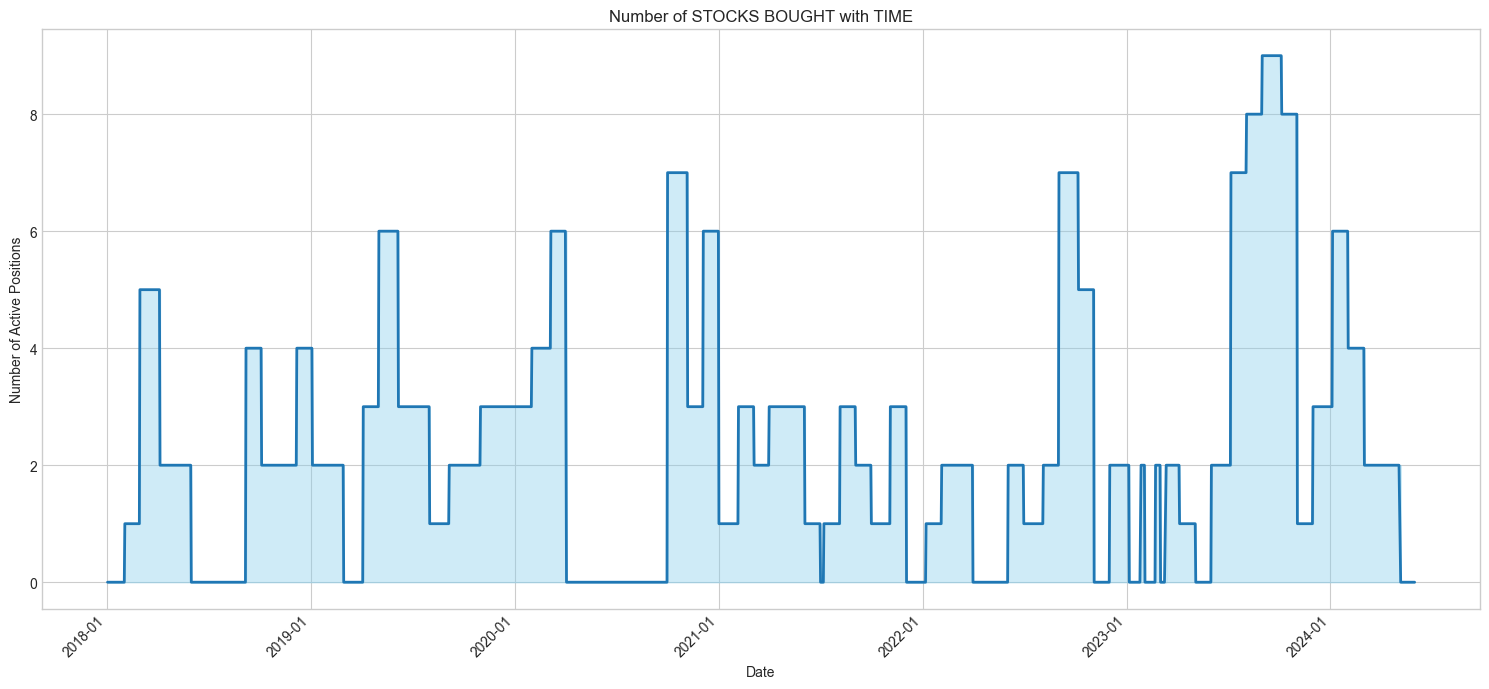

Percentage of CAPITAL INVESTED with TIME


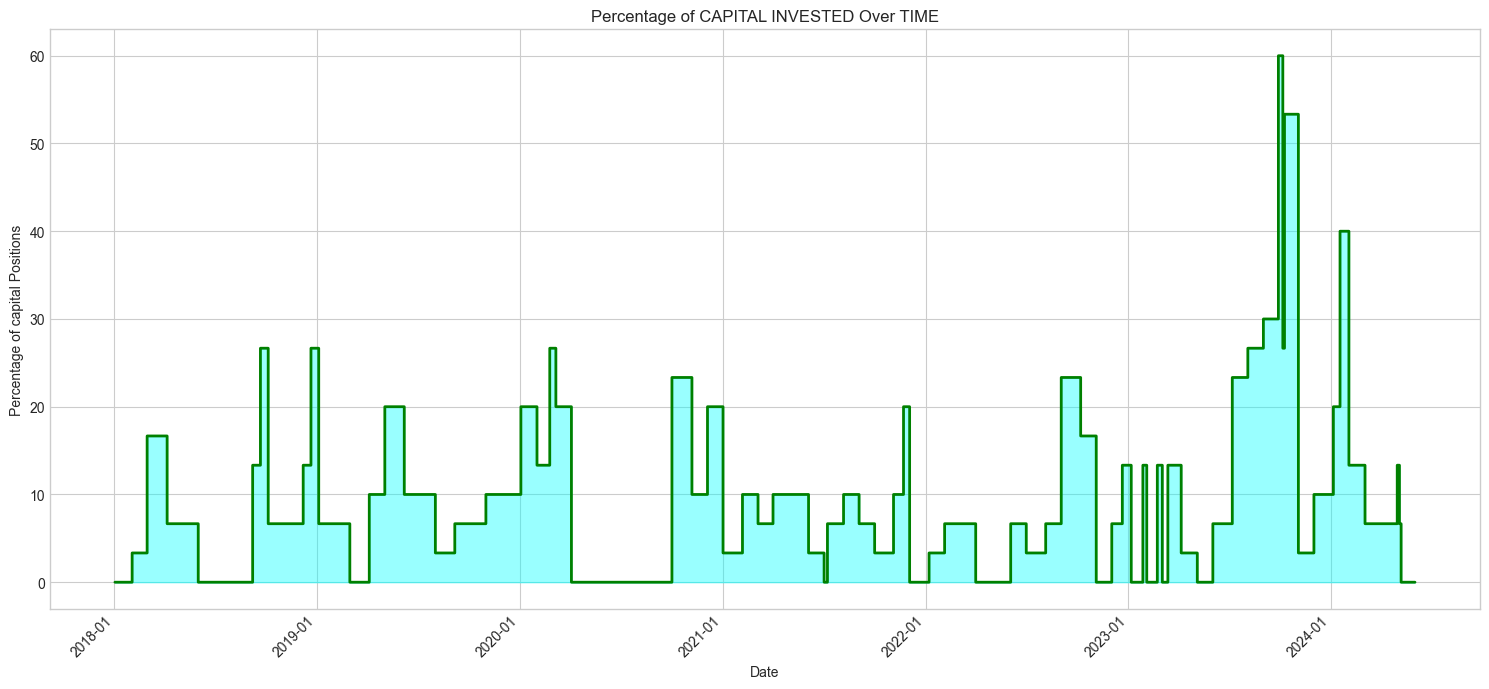

In [ ]:

weights_df = pd.read_csv('auxilary/backtester_weights.csv', index_col=0, parse_dates=True)
print("---------------Successfully loaded 'results/signals.csv'---------------")

print("Number of STOCKS BOUGHT with TIME")
weights_df=weights_df.ffill()
weights_df=weights_df[TRADING_START_DATE:END_DATE]
invested_stocks_count = (weights_df > 0).sum(axis=1)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 7))
invested_stocks_count.plot(
    ax=ax,
    title='Number of STOCKS BOUGHT with TIME',
    xlabel='Date',
    ylabel='Number of Active Positions',
    lw=2
)
ax.fill_between(
        invested_stocks_count.index, 
        invested_stocks_count.values, 
        step='post', 
        color='skyblue', 
        alpha=0.4 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()



print("Percentage of CAPITAL INVESTED with TIME")
weights_df = pd.read_csv('auxilary/backtester_weights.csv', index_col=0, parse_dates=True)
weights_df=weights_df*100
weights_df=weights_df.ffill()
weights_df=weights_df[TRADING_START_DATE:END_DATE]
invested_stocks_count = weights_df.sum(axis=1)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 7))
invested_stocks_count.plot(
    ax=ax,
    title='Percentage of CAPITAL INVESTED Over TIME',
    xlabel='Date',
    ylabel='Percentage of capital Positions',
    lw=2,
    drawstyle='steps-post',
    color='green'
)
ax.fill_between(
        invested_stocks_count.index, 
        invested_stocks_count.values, 
        step='post', 
        color='cyan', 
        alpha=0.4 
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import vectorbt as vbt
from IPython.display import display

# --- 1. Load Data and Define Parameters ---
# (Your data loading and parameter lists remain the same)
data = pd.read_csv(
    'src/all_ohlcv_clipped.csv',
    index_col=0, header=[0, 1], parse_dates=True
)
data = data.sort_index()
INITIAL_CAPITAL = 100000

# ... (parameter lists) ...
rolling_period_list = [12,16,20,24,28,32,36,40,44,48,52,56,60,64]
mean_period_list = [12,16,20,24,28,32,36,40,44,48,52,56,60,64]
rolling_threshold_list = [0]
dilute_to_list=[15]

all_results = []
close_prices_full = data.xs('close', level=1, axis=1)
weekly_returns = np.log(close_prices_full / close_prices_full.shift(1))
count=0
tot=len(rolling_period_list)*len(mean_period_list)*len(rolling_threshold_list)*len(dilute_to_list)
print("\n----------------------------------- Starting Parameter Optimization Grid Search -----------------------------------\n------------------------------------ Results will be stored in all_results.csv ------------------------------------")

# --- 2. Main Loop ---
for rolling_period in rolling_period_list:
    for mean_period in mean_period_list:
        for rolling_threshold in rolling_threshold_list:
            for dilute_to in dilute_to_list:
                # --- A. Generate Signals and weights ---
                count+=1
                print(f"{count}/{tot}---------Running for:\t roll={rolling_period},\t mean={mean_period},\t roll_thr={rolling_threshold},\tdilute_to={dilute_to}\t\t-----------")
                z_score_df,z_scores_mean_df=z_score( rolling_threshold, rolling_period, mean_period,mode='looptest')
                weights_generation(START_DATE, END_DATE,TRADING_START_DATE, Z_MEAN,dilute_to,z_scores_df,z_scores_mean_df,INITIAL_CAPITAL, NUM_STOCKS_ACTIVE, ZSCORE_THRESHOLD,mode='looptest')

                fresh_strategy = Strategy_looptest()
                
                backtester = Backtester(data, INITIAL_CAPITAL,TRADING_START_DATE)
                backtester.run(mode='looptest')
                pf = backtester.vectorbt_run(rolling_period,mean_period,rolling_threshold,dilute_to,mode='looptest')

                all_results.append(pf)
                all_results_df=pd.DataFrame(all_results)
                all_results_df.to_csv('all_results.csv')
            
# --- The rest of your script for displaying results ---
if all_results:
    results_df = pd.DataFrame(all_results)
    final_3d_df = results_df.set_index(['rolling_period', 'mean_period', 'rolling_threshold','dilute_to'])
    print("\n-------------------------------------------- Final 3D Results DataFrame --------------------------------------------")
    display(final_3d_df.round(4))



----------------------------------- Starting Parameter Optimization Grid Search -----------------------------------
------------------------------------ Results will be stored in all_results.csv ------------------------------------
1/196---------Running for:	 roll=12,	 mean=12,	 roll_thr=0,	dilute_to=15		-----------
Rebalancing dates: 2024-05-06 00:00:00


100%|██████████| 1587/1587 [00:09<00:00, 174.60it/s]


2/196---------Running for:	 roll=12,	 mean=16,	 roll_thr=0,	dilute_to=15		-----------
Rebalancing dates: 2024-05-06 00:00:00


100%|██████████| 1587/1587 [00:08<00:00, 178.68it/s]


3/196---------Running for:	 roll=12,	 mean=20,	 roll_thr=0,	dilute_to=15		-----------
Rebalancing dates: 2024-05-06 00:00:00


...

100%|██████████| 1587/1587 [00:08<00:00, 182.66it/s]


196/196---------Running for:	 roll=64,	 mean=64,	 roll_thr=0,	dilute_to=15		-----------
Rebalancing dates: 2024-05-06 00:00:00


100%|██████████| 1587/1587 [00:08<00:00, 182.57it/s]



-------------------------------------------- Final 3D Results DataFrame --------------------------------------------


Total Return [%]  Max Drawdown [%]  Sharpe Ratio
rolling_period mean_period rolling_threshold dilute_to                                                  
12             12          0                 15                  28.6012            8.0931        1.3471
               16          0                 15                  25.3563            6.5169        1.3440
               20          0                 15                  20.7110            5.1127        1.1838
               24          0                 15                   3.6468            7.4549        0.2253
               28          0                 15                   2.4926            8.7068        0.2125
...                                                                  ...               ...           ...
64             48          0                 15                  36.8776            5.6449        1.7533
               52          0                 15                  39.3838            4.7895        1.9670
               56          0                 15                  32.9395            5.0124        1.7777
               60          0                 15                  32.7947            4.9832        1.9211
               64          0                 15                  27.5278            4.8057        1.6652

[196 rows x 3 columns]